# Austin-San Marcos Housing Affordability Analysis
## Milestone 2: Data Cleaning & Exploratory Data Analysis (EDA)

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")

## 1. Data Loading Pipeline

We load data from four distinct sources covering market conditions, home values, incomes needed, and the geographic distribution of affordable housing.

In [27]:
# Redfin market data (Austin & San Marcos)
redfin_df = pd.read_csv('data/redfin_austin_sanmarcos.csv', encoding='utf-16', sep='	')

# Zillow ZHVI city-level home values
zhvi_df = pd.read_csv('data/zillow_zhvi_city.csv')

# Zillow Income Needed at Metro level
income_df = pd.read_csv('data/zillow_income_needed_metro.csv')

# City of Austin affordable housing inventory
housing_df = pd.read_csv('data/austin_affordable_housing.csv')

## 2. Data Cleaning Pipeline

The datasets require specific transformations, particularly concerning datetime parsing, wide-to-long melting of Zillow data, and numeric formatting of Redfin variables. We encapsulate the logic within functions for reproducibility.

In [28]:
def clean_redfin(df):
    clean_df = df.copy()
    # Strip whitespace from columns
    clean_df.columns = [col.strip() for col in clean_df.columns]
    
    # Convert 'Week of Period End' to datetime
    clean_df['Week of Period End'] = pd.to_datetime(clean_df['Week of Period End'])
    
    # Convert 'Median Sale Price' from string '$205K' to numeric
    clean_df['Median Sale Price'] = clean_df['Median Sale Price'].replace({r'\$': '', r'K': '000'}, regex=True).astype(float)
    
    # Convert numeric columns that have commas
    cols_with_commas = ['Homes Sold', 'New Listings', 'Inventory']
    for col in cols_with_commas:
        if col in clean_df.columns and clean_df[col].dtype == object:
            clean_df[col] = clean_df[col].astype(str).str.replace(',', '', regex=False).astype(float)
    return clean_df

redfin_clean = clean_redfin(redfin_df)
print("Redfin data after cleaning-> Shape:", redfin_clean.shape)

Redfin data after cleaning-> Shape: (340, 20)


In [29]:
def melt_zillow_data(df, value_name='Value'):
    # Zillow data is often in wide format with date columns
    date_cols = [col for col in df.columns if col.startswith('20')]
    id_cols = [col for col in df.columns if col not in date_cols]
    
    melted = df.melt(id_vars=id_cols, value_vars=date_cols, var_name='Date', value_name=value_name)
    melted['Date'] = pd.to_datetime(melted['Date'])
    
    # Drop rows where the value is missing
    melted = melted.dropna(subset=[value_name])
    return melted

zhvi_clean = melt_zillow_data(zhvi_df, value_name='ZHVI')
print("ZHVI data after cleaning-> Shape:", zhvi_clean.shape)

# Transform Income Needed dataset
income_clean = melt_zillow_data(income_df, value_name='Income_Needed')
# Filter for Austin Metro
income_austin = income_clean[income_clean['RegionName'].str.contains('Austin', na=False)].copy()
print("Income data after cleaning-> Shape:", income_austin.shape)

ZHVI data after cleaning-> Shape: (544, 10)
Income data after cleaning-> Shape: (170, 7)


In [30]:
def clean_housing(df):
    clean_df = df.copy()
    # Drop rows without coordinate mapping
    clean_df = clean_df.dropna(subset=['Longitude', 'Latitude'])
    
    # Ensure ZIP code is categorical
    clean_df['ZIP'] = clean_df['ZIP'].astype(str).str.replace('.0', '', regex=False)
    
    # Fill missing Council District
    if 'Council_District' in clean_df.columns:
        clean_df['Council_District'] = clean_df['Council_District'].fillna('Unknown')
    return clean_df

housing_clean = clean_housing(housing_df)
print("Housing data after cleaning -> Shape:", housing_clean.shape)

Housing data after cleaning -> Shape: (2412, 52)


## 3. Exploratory Data Analysis (EDA)

In this section, we present 6 static visualizations investigating the dynamics of the Austin-San Marcos housing market and the spatial geography of the affordable housing stock.

### Visualization 1: Zillow Home Value Index (ZHVI) Over Time
This line chart compares the generic home value trends in Austin versus San Marcos. It highlights the drastic spike in Austin home prices particularly after 2020, and shows how San Marcos tracks similarly but at a considerably more affordable baseline.

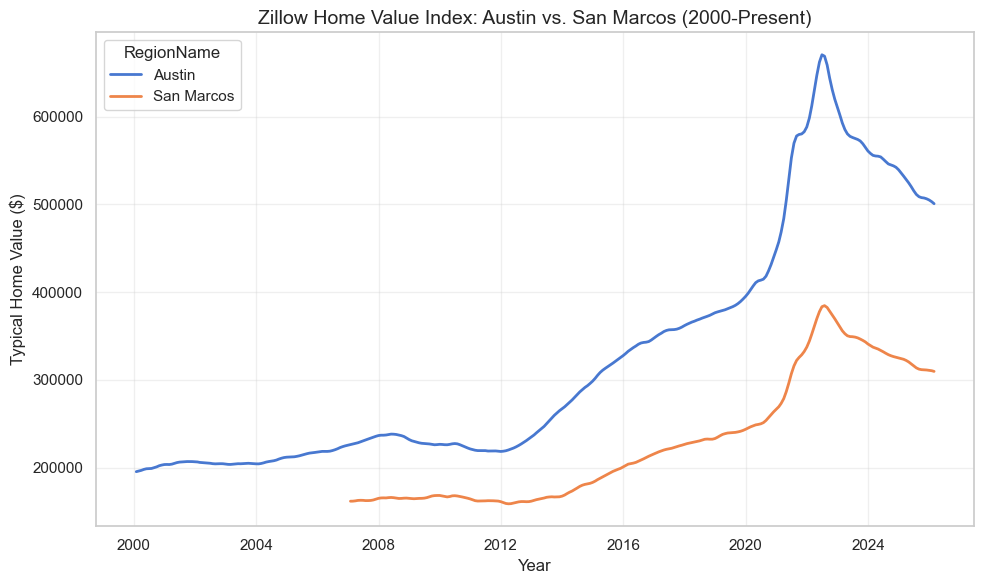

In [31]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=zhvi_clean, x='Date', y='ZHVI', hue='RegionName', linewidth=2)
plt.title('Zillow Home Value Index: Austin vs. San Marcos (2000-Present)', fontsize=14)
plt.ylabel('Typical Home Value ($)')
plt.xlabel('Year')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Visualization 2: Redfin Median Sale Price Distribution
A boxplot comparing the distribution of weekly median sale prices over the entire period between Austin and San Marcos. This provides an understanding of the variance and typical pricing floors/ceilings in both submarkets, showcasing Austin's massive upper tail of expensive properties.

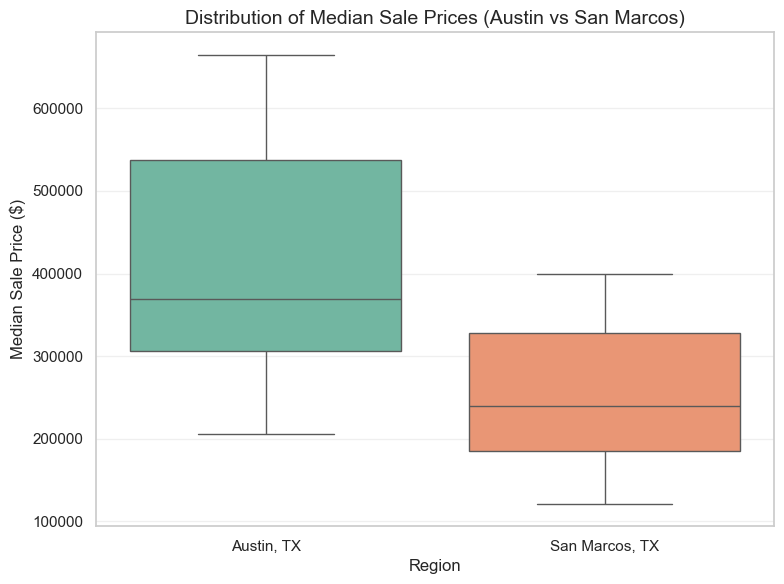

In [32]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=redfin_clean, x='Region', y='Median Sale Price', palette='Set2')
plt.title('Distribution of Median Sale Prices (Austin vs San Marcos)', fontsize=14)
plt.ylabel('Median Sale Price ($)')
plt.xlabel('Region')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### Visualization 3: Rising Income Needed for a Mortgage in Austin Metro
This chart visualizes the estimated household income required to comfortably afford a typical home in the Austin Metro area over the course of a decade, revealing a massive affordability wall hit around 2022 where the required income doubled.

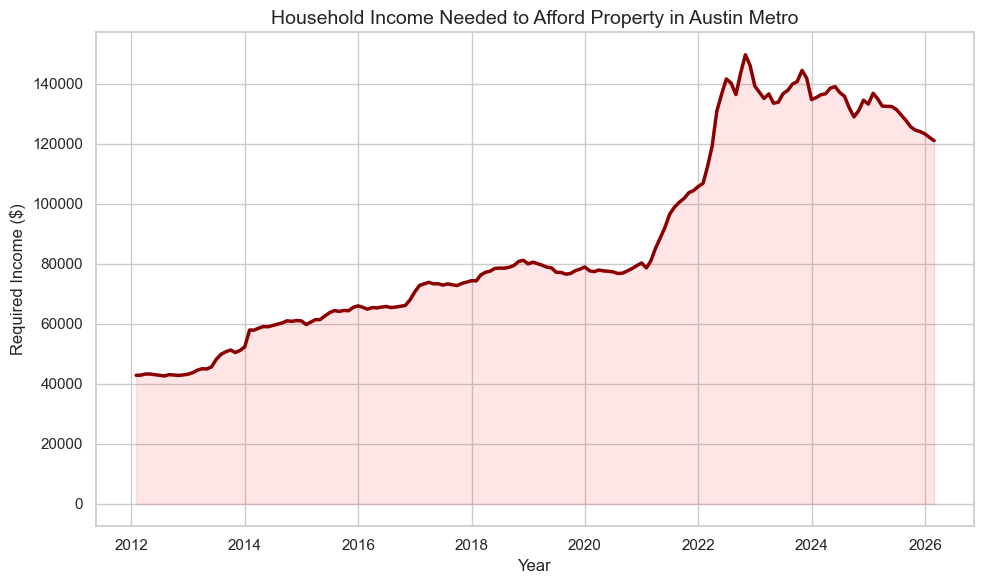

In [33]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=income_austin, x='Date', y='Income_Needed', color='darkred', linewidth=2.5)
plt.title('Household Income Needed to Afford Property in Austin Metro', fontsize=14)
plt.ylabel('Required Income ($)')
plt.xlabel('Year')
plt.fill_between(income_austin['Date'], income_austin['Income_Needed'], color='red', alpha=0.1)
plt.tight_layout()
plt.show()

### Visualization 4: Supply & Demand Dynamics (Inventory vs. Homes Sold)
By looking at Austin's active Inventory versus the number of Homes Sold on a timeline, we can estimate market tightness. We observe the dramatic plunge in inventory around 2021, paired with high sales, transitioning later to a stark inventory build-up.

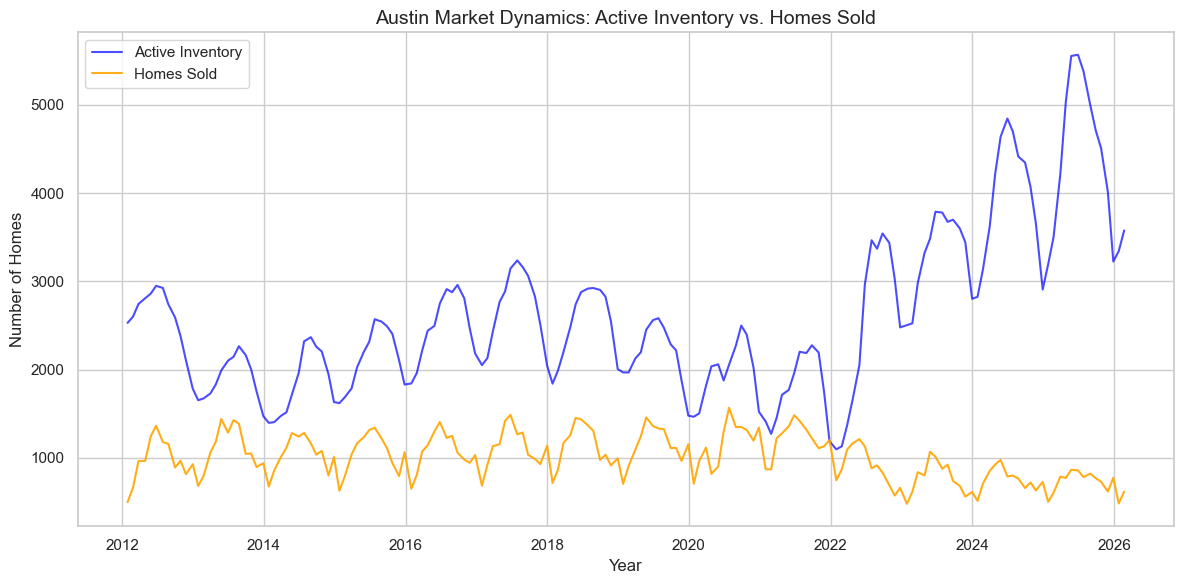

In [34]:
austin_redfin = redfin_clean[redfin_clean['Region'] == 'Austin, TX']

plt.figure(figsize=(12, 6))
plt.plot(austin_redfin['Week of Period End'], austin_redfin['Inventory'], label='Active Inventory', color='blue', alpha=0.7)
plt.plot(austin_redfin['Week of Period End'], austin_redfin['Homes Sold'], label='Homes Sold', color='orange', alpha=0.9)
plt.title('Austin Market Dynamics: Active Inventory vs. Homes Sold', fontsize=14)
plt.ylabel('Number of Homes')
plt.xlabel('Year')
plt.legend()
plt.tight_layout()
plt.show()

### Visualization 5: Geographic Concentration of Affordable Housing by ZIP Code
**Caption:** This bar chart illustrates the top 15 ZIP codes in Austin with the highest concentration of affordable housing projects. It immediately reveals geographic disparity, showing that most inventory is highly localized in a few specific zip codes (e.g., East and South Austin).

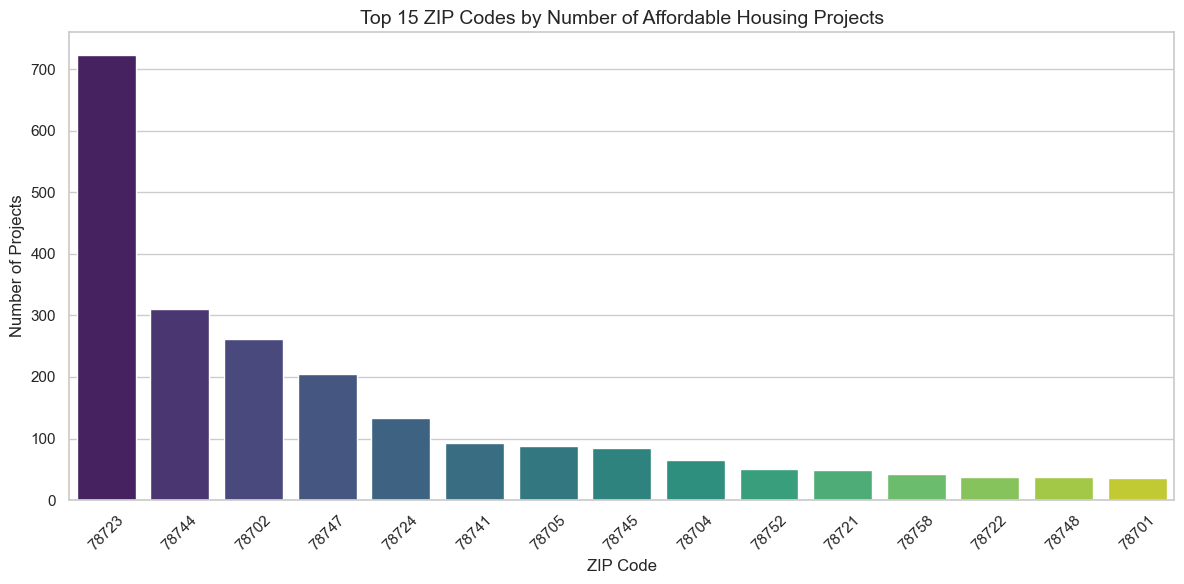

In [35]:
plt.figure(figsize=(12, 6))
top_zips = housing_clean['ZIP'].value_counts().head(15)
sns.barplot(x=top_zips.index, y=top_zips.values, palette='viridis')
plt.title('Top 15 ZIP Codes by Number of Affordable Housing Projects', fontsize=14)
plt.ylabel('Number of Projects')
plt.xlabel('ZIP Code')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Visualization 6: Geographic Scatter of Affordable Housing Locations
A standard scatter plot simulating a map of Austin using latitude and longitude coordinates. Each point represents an affordable housing project. The overlapping points create darker clusters, illustrating distinct hot spots and "deserts" for affordable housing development.

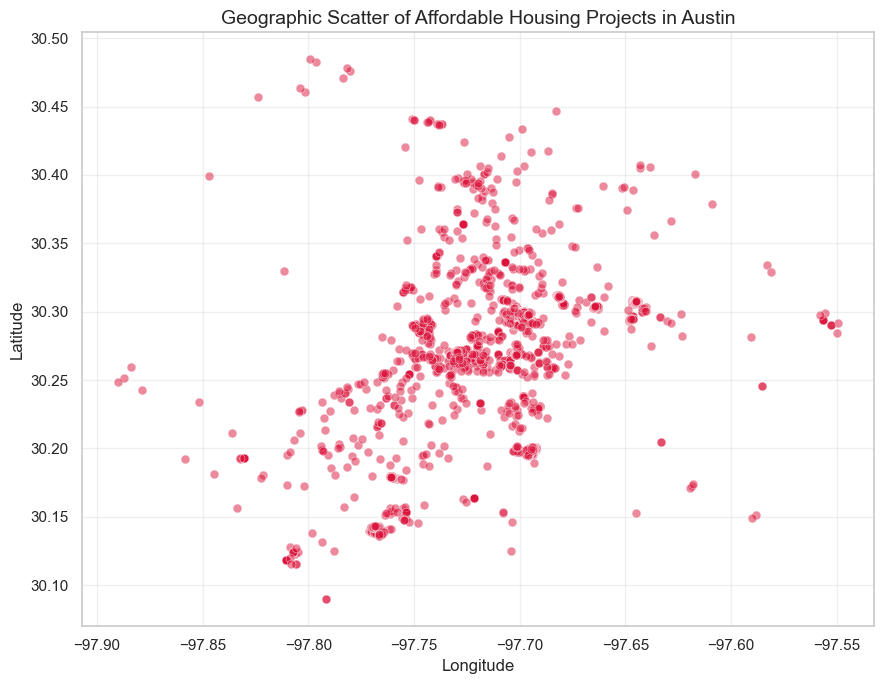

In [36]:
plt.figure(figsize=(9, 7))
sns.scatterplot(data=housing_clean, x='Longitude', y='Latitude', alpha=0.5, s=40, color='crimson')
plt.title('Geographic Scatter of Affordable Housing Projects in Austin', fontsize=14)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Summary of Initial Findings and Hypotheses

### Initial Findings:
1. **Divergent Absolute Prices but Synchronized Trends:** Both Austin and San Marcos experienced steep home value appreciation curves starting in late 2020 and peaking between 2021-2022. However, Austin’s peak was drastically higher. San Marcos represents a consistently cheaper alternative, though it suffered proportional inflation.
2. **The Affordability Wall:** The income needed to procure a mortgage in the Austin Metro nearly doubled over a 3-year period around the pandemic, jumping from roughly ~$60,000 to over ~$140,000, severely pricing out the median earner.
3. **Uneven Spatial Distribution:** The affordable housing inventory in Austin is predominantly clumped into a small subset of ZIP codes, rather than being evenly distributed. Both the bar chart and spatial density map corroborate severe geographic clustering, leaving entire swathes of the city as "affordable housing deserts".

### Hypotheses for Further Exploration:
- **Hypothesis 1 (Displacement into San Marcos):** As the true income required to buy in Austin surges past median wage limits, homebuyer demand physically spills over down the I-35 corridor to San Marcos, theoretically closing the percentage valuation gap between Austin and San Marcos over time.
- **Hypothesis 2 (Inventory Shock Effect):** The sharp increase in active housing inventory depicted in the most recent Redfin data points is negatively correlated with median sale prices, suggesting the market is undergoing a cooling or corrective period.
- **Hypothesis 3 (Affordable Housing Inequality):** The regions (ZIP codes) with the highest concentration of affordable housing overlap significantly with historically lower-income or rapidly gentrifying neighborhoods, while West/Central Austin ZIPs have near-zero representation in the affordable housing pipeline.